In [1]:
import sqlite3
import requests
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

#API Key
KGAT_335fad76d17cbe7515ebb6aebbaed48e

In [3]:
import os
print(os.path.exists(r"C:\Users\Gaurav.Mathur\.kaggle\kaggle.json"))

True


In [4]:
os.environ["KAGGLE_USERNAME"] = "dhruv9999999"
os.environ["KAGGLE_KEY"] = "KGAT_335fad76d17cbe7515ebb6aebbaed48e"

In [5]:
#Downloading the required dataset
!kaggle datasets download -d anandshaw2001/amazon-product-sales-2025

Dataset URL: https://www.kaggle.com/datasets/anandshaw2001/amazon-product-sales-2025
License(s): CC0-1.0




  0%|          | 0.00/388k [00:00<?, ?B/s]
100%|##########| 388k/388k [00:00<00:00, 420kB/s]
100%|##########| 388k/388k [00:01<00:00, 397kB/s]


In [7]:
#Extracting the dataset
import zipfile
with zipfile.ZipFile("amazon-product-sales-2025.zip",'r') as zip_ref:
    zip_ref.extractall("../data/")

In [9]:
#Loading it to Pandas
df = pd.read_csv("../data/amazon_sales_2025_INR.csv")
df.head()

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,2025-01-25,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,2025-08-28,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,2025-02-27,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,2025-02-24,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,2025-06-15,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15000 non-null  object 
 1   Date              15000 non-null  object 
 2   Customer_ID       15000 non-null  object 
 3   Product_Category  15000 non-null  object 
 4   Product_Name      15000 non-null  object 
 5   Quantity          15000 non-null  int64  
 6   Unit_Price_INR    15000 non-null  float64
 7   Total_Sales_INR   15000 non-null  float64
 8   Payment_Method    15000 non-null  object 
 9   Delivery_Status   15000 non-null  object 
 10  Review_Rating     15000 non-null  int64  
 11  Review_Text       15000 non-null  object 
 12  State             15000 non-null  object 
 13  Country           15000 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.6+ MB


In [11]:
#Converting date and adding product_id for the products
df["Date"] = pd.to_datetime(df["Date"])

df["Product_ID"] = df["Product_Name"].astype('category').cat.codes

df.head()

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country,Product_ID
0,ORD100000,2025-01-25,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India,4
1,ORD100001,2025-08-28,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India,7
2,ORD100002,2025-02-27,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India,22
3,ORD100003,2025-02-24,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India,8
4,ORD100004,2025-06-15,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India,15


In [12]:
#Creating a database
conn = sqlite3.connect("../databases/ecommerce_sales.db")

#Create a cursor
cursor = conn.cursor()

print("Database created successfully")

Database created successfully


In [13]:
cursor.execute("""
CREATE TABLE orders(
order_id TEXT PRIMARY KEY,
customer_id TEXT,
order_date TEXT,
product_id INTEGER,
quantity INTEGER,
total_sales_inr REAL
)
""")

cursor.execute("""
CREATE TABLE products(
product_id INTEGER PRIMARY KEY,
product_name TEXT,
product_category TEXT,
unit_price_inr REAL
)
""")

cursor.execute("""
CREATE TABLE customers(
customer_id TEXT PRIMARY KEY,
state TEXT,
country TEXT
)
""")

cursor.execute("""
CREATE TABLE payments(
order_id TEXT,
payment_method TEXT,
FOREIGN KEY (order_id) REFERENCES orders(order_id)
)
""")

cursor.execute("""
CREATE TABLE delivery(
order_id TEXT,
delivery_status TEXT,
FOREIGN KEY (order_id) REFERENCES orders(order_id)
)
""")

cursor.execute("""
CREATE TABLE reviews(
order_id TEXT,
review_rating INTEGER,
review_text TEXT,
FOREIGN KEY (order_id) REFERENCES orders(order_id)
)
""")

conn.commit()
print("Tables created successfully!")

Tables created successfully!


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          15000 non-null  object        
 1   Date              15000 non-null  datetime64[ns]
 2   Customer_ID       15000 non-null  object        
 3   Product_Category  15000 non-null  object        
 4   Product_Name      15000 non-null  object        
 5   Quantity          15000 non-null  int64         
 6   Unit_Price_INR    15000 non-null  float64       
 7   Total_Sales_INR   15000 non-null  float64       
 8   Payment_Method    15000 non-null  object        
 9   Delivery_Status   15000 non-null  object        
 10  Review_Rating     15000 non-null  int64         
 11  Review_Text       15000 non-null  object        
 12  State             15000 non-null  object        
 13  Country           15000 non-null  object        
 14  Product_ID        1500

In [15]:
df.columns = df.columns.str.lower() #Converting all columns to lowercase
df.rename(columns = {"date" : "order_date"}, inplace = True)

In [16]:
#Creating separate dataframes for inserting data into sql tables
customers = df[["customer_id", "state", "country"]]
customers = customers.groupby('customer_id').first().reset_index()

products = df[["product_id", "product_name", "product_category", "unit_price_inr"]]
products = products.groupby('product_id').first().reset_index()

orders = df[["order_id", "customer_id", "order_date", "product_id", "quantity", "total_sales_inr"]]

payments = df[["order_id", "payment_method"]]

delivery = df[["order_id", "delivery_status"]]

reviews = df[["order_id", "review_rating", "review_text"]]

In [17]:
cursor.execute("DELETE FROM customers")
cursor.execute("DELETE FROM products")
cursor.execute("DELETE FROM payments")
cursor.execute("DELETE FROM delivery")
cursor.execute("DELETE FROM reviews")

In [18]:
#Now the data insertion
customers.to_sql('customers',conn, if_exists = 'append', index = False)

products.to_sql('products',conn, if_exists = 'append', index = False)

orders.to_sql('orders',conn, if_exists = 'append', index = False)

payments.to_sql('payments',conn, if_exists = 'append', index = False)

delivery.to_sql('delivery',conn, if_exists = 'append', index = False)

reviews.to_sql('reviews',conn, if_exists = 'append', index = False)

15000

PROBLEM 1: TOTAL REVENUE

In [19]:
#total revenue
pd.read_sql("SELECT SUM(total_sales_inr) AS total_revenue FROM orders", conn)

,total_revenue
0,1.118162e+09


PROBLEM 2: TOP 5 SELLING PRODUCTS

In [21]:
#top 5 selling products
top_products = pd.read_sql("""
SELECT p.product_name, SUM(o.quantity) AS total_quantity FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_quantity DESC
LIMIT 5
""", conn)
top_products

,product_name,total_quantity
0,Perfume,1887
1,Children's Book,1881
2,Headphones,1880
3,Lipstick,1871
4,Hair Dryer,1839


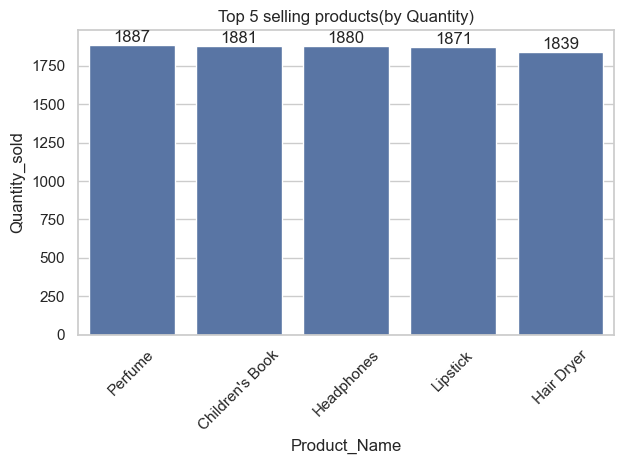

In [22]:
#visualising the data
sns.set(style = 'whitegrid')
ax = sns.barplot(
    x = 'product_name',
    y = 'total_quantity',
    data = top_products
)

for i in ax.containers:
    ax.bar_label(i)
    
plt.title("Top 5 selling products(by Quantity)")
plt.xlabel('Product_Name')
plt.ylabel('Quantity_sold')
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

Insight: A small group of products contributes significantly to overall sales, indicating that customer demand is concentrated
on a few popular items. These products can be prioritized for inventory management and promotional strategies.

PROBLEM 3: TOTAL REVENUE GENERATED BY EACH STATE

In [23]:
#Revenue by state
total_revenue = pd.read_sql("""
SELECT c.state, SUM(o.total_sales_inr) AS revenue FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.state
ORDER BY revenue DESC
""", conn)
total_revenue

,state,revenue
0,Sikkim,45833128.09
1,Chhattisgarh,44115661.94
2,Nagaland,43874809.55
3,Tamil Nadu,43478958.19
4,West Bengal,43372169.50
5,Madhya Pradesh,43235529.78
6,Tripura,42181418.26
7,Punjab,41652896.01
8,Himachal Pradesh,41585418.63
9,Rajasthan,41456185.92


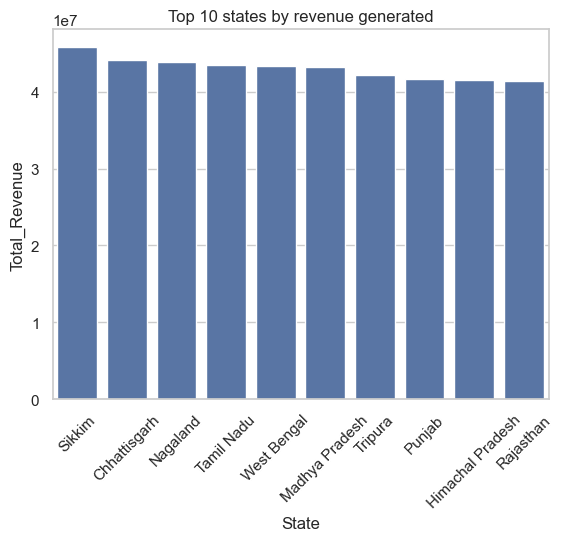

In [25]:
#visualising results
ax = sns.barplot(
    x = 'state', y = 'revenue', data = total_revenue.head(10)
)

plt.title("Top 10 states by revenue generated")
plt.xlabel("State")
plt.ylabel("Total_Revenue")
plt.xticks(rotation = 45)
plt.show()

Insight: Revenue Distribution across states is uneven, with certain states contributing a significantly higher share. This suggests
stronger market presence or higher purchasing power in these regions, making them key focus areas for business expansion.

PROBLEM 4: PAYMENT METHOD DISTRIBUTION

In [26]:
#Payment method distribution
payment_distribution = pd.read_sql("""
SELECT payment_method, COUNT(*) AS total_orders FROM payments
GROUP BY payment_method
ORDER BY total_orders DESC
""", conn)

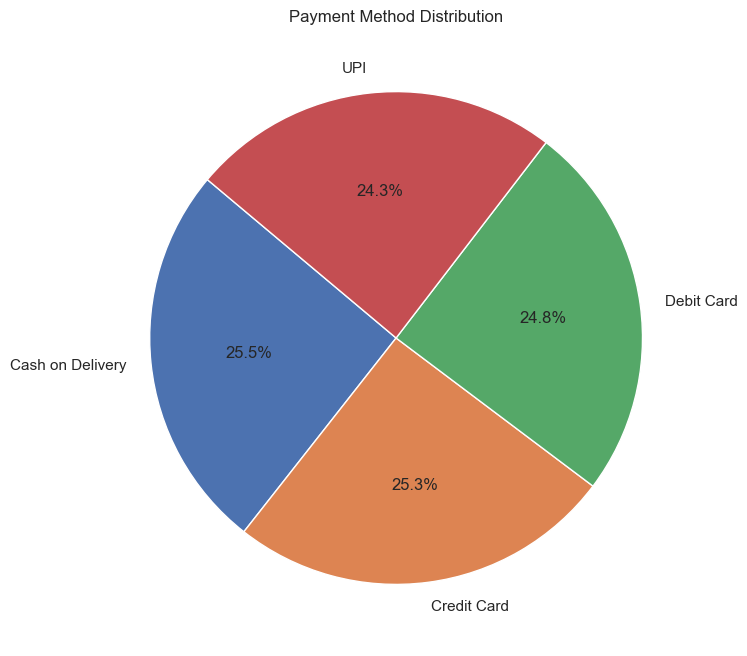

In [29]:
#visualising results
plt.figure(figsize = (8,8))
plt.pie(
    payment_distribution['total_orders'],
    labels = payment_distribution['payment_method'],
    autopct = '%1.1f%%',
    startangle = 140
)

plt.title("Payment Method Distribution")
plt.show()

Insight: The pie chart shows the paymemt method distribution, in which it can be clearly seen that customers preferred Cash on
         Delivery the most as their mode of payment, followed by credit and debit cards and lastly UPI.

PROBLEM 5: AVERAGE RATING FOR ALL ORDERS

In [30]:
#Average rating
pd.read_sql("""
SELECT AVG(review_rating) AS avg_rating
FROM reviews
""", conn)

,avg_rating
0,3.040133


PROBLEM 6: TOTAL ORDERS FOR EACH STATE

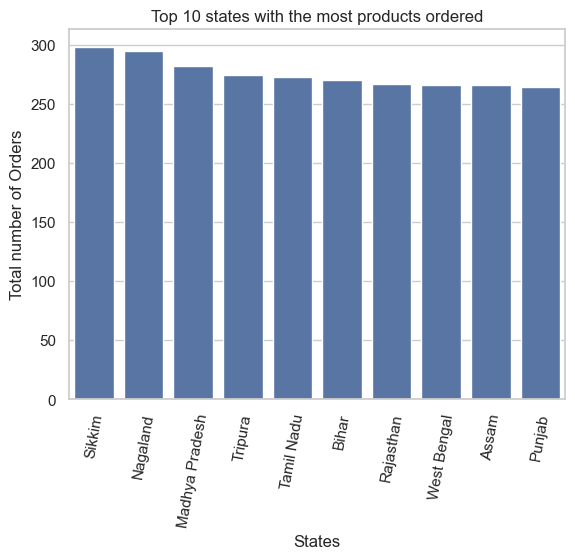

In [31]:
#Total orders by state
total_orders = pd.read_sql("""
SELECT state, COUNT(*) AS total_orders
FROM customers
GROUP BY state
ORDER BY total_orders DESC
LIMIT 10
""", conn)

sns.barplot(
    x = 'state', y = 'total_orders', data = total_orders
)

plt.xlabel('States')
plt.ylabel('Total number of Orders')
plt.title('Top 10 states with the most products ordered')
plt.xticks(rotation = 80)
plt.show()

Insight: Order volume is heavily concentrated in a few states, indicating higher customer engagement and demand in these regions. These states
can be targeted for faster delivery services and localized marketing campaigns.

PROBLEM 7: AVERAGE ORDER VALUE PER CUSTOMER

In [32]:
#Average order value
pd.read_sql("""
SELECT ROUND(AVG(total_sales_inr),2) AS avg_order_value
FROM orders
""", conn)

,avg_order_value
0,74544.12


PROBLEM 8: TOTAL REVENUE GENERATED BY EACH CATEGORY

In [34]:
#Total revenue per category
revenue_by_category = pd.read_sql("""
SELECT p.product_category, SUM(o.total_sales_inr) as total_revenue
FROM orders o
JOIN products p ON p.product_id = o.product_id
GROUP BY p.product_category
ORDER BY total_revenue DESC
""", conn)
revenue_by_category

,product_category,total_revenue
0,Beauty,2.274896e+08
1,Electronics,2.265649e+08
2,Books,2.249992e+08
3,Clothing,2.224093e+08
4,Home & Kitchen,2.166987e+08


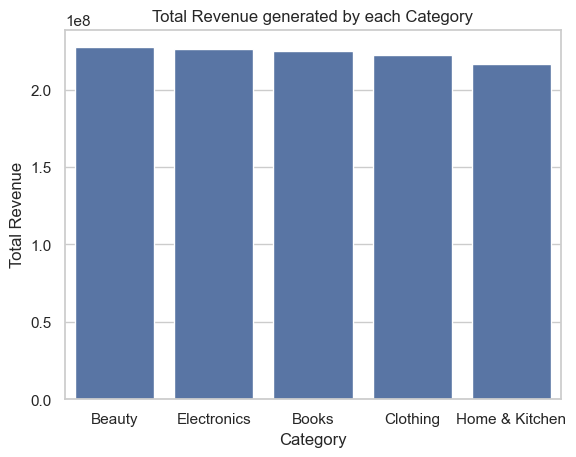

In [35]:
#visualising results
sns.barplot(
    x = 'product_category', y = 'total_revenue', data = revenue_by_category
)

plt.title("Total Revenue generated by each Category")
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.show()

Insight: Certain product categories generate significantly higher revenue than others, highlighting their importance as primary
revenue drivers. Focusing on these categories can help maximize profitability and business growth.

PROBLEM 9: THE TOP 3 STATES WHICH GENERATED THE HIGHEST REVENUE

In [36]:
#Top 3 states by revenue
pd.read_sql("""
SELECT c.state, SUM(o.total_sales_inr) AS total_revenue
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
GROUP BY c.state
ORDER BY total_revenue DESC
LIMIT 3
""", conn)

,state,total_revenue
0,Sikkim,45833128.09
1,Chhattisgarh,44115661.94
2,Nagaland,43874809.55


PROBLEM 10: AVERAGE RATING FOR EACH PRODUCT

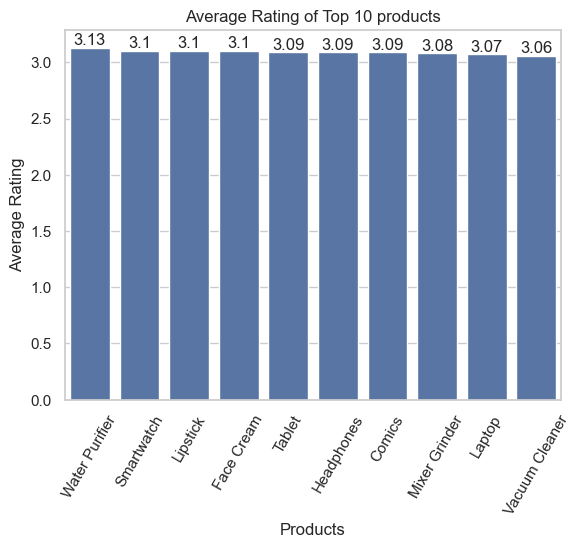

In [37]:
avg_rating = pd.read_sql("""
SELECT p.product_name, ROUND(AVG(review_rating), 2) AS avg_rating
FROM reviews r
JOIN orders o ON r.order_id = o.order_id
JOIN products p ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY avg_rating DESC
LIMIT 10
""", conn)

ax = sns.barplot(
    x = 'product_name', y = 'avg_rating', data = avg_rating
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Average Rating of Top 10 products")
plt.xlabel('Products')
plt.ylabel('Average Rating')
plt.xticks(rotation = 60)
plt.show()

Insight: Top-rated products maintain consistently high customer satisfaction, especially those with significant review counts

In [38]:
#Count of delivered vs pending/cancelled orders
pd.read_sql("""
SELECT delivery_status, COUNT(*) AS status_count
FROM delivery
GROUP BY delivery_status
ORDER BY status_count DESC
""", conn)

,delivery_status,status_count
0,Delivered,5075
1,Pending,5044
2,Returned,4881


PROBLEM 11: HOW MANY UNIQUE CUSTOMERS ARE THERE IN TOTAL?

In [39]:
#total number of unique customers
pd.read_sql("SELECT COUNT(*) AS total FROM customers", conn)

,total
0,7259


PROBLEM 12: TOP 5 CUSTOMERS WHO SPENT THE MOST

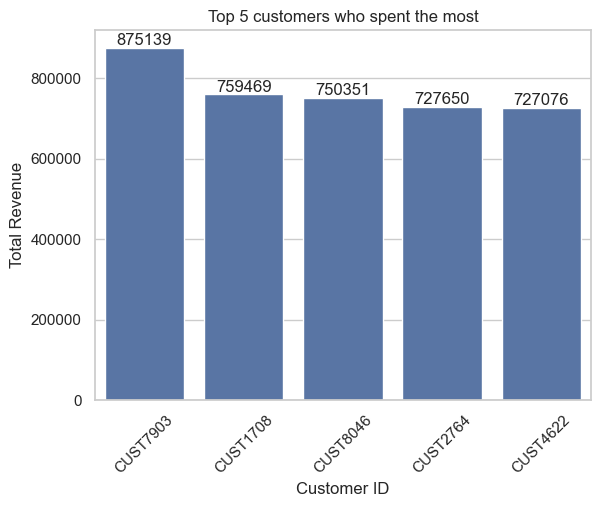

In [40]:
top_customers = pd.read_sql("""
SELECT c.customer_id, SUM(o.total_sales_inr) as total_revenue
FROM orders o
JOIN customers c ON  o.customer_id = c.customer_id
GROUP BY c.customer_id
ORDER BY total_revenue DESC
LIMIT 5
""", conn)

ax = sns.barplot(
    x = 'customer_id', y = 'total_revenue', data = top_customers
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 5 customers who spent the most")
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation = 45)
plt.show()

Insight: Overall, the analysis highlights key revenue drivers, high-performing regions and valuable customer segments, providing actionable
insights for strategic decision-making.

PROBLEM 13: MONTHLY REVENUE TREND

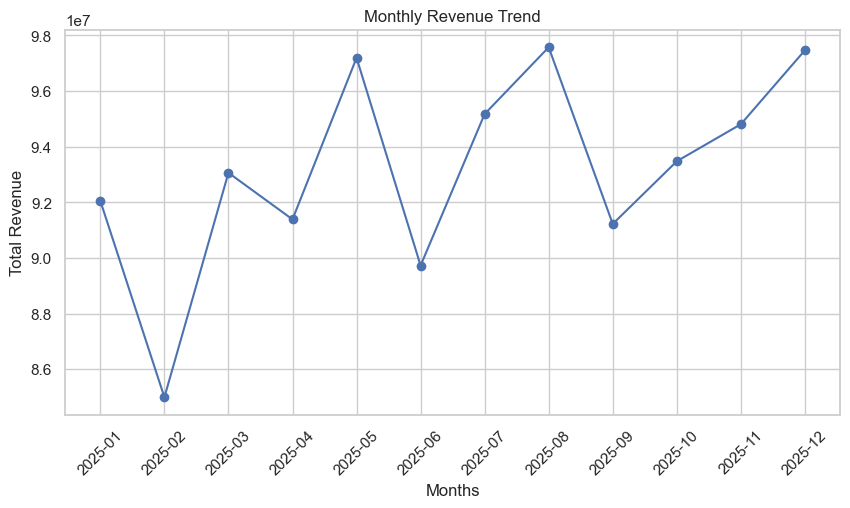

In [41]:
monthly_rev = pd.read_sql("""
SELECT strftime("%Y-%m", order_date) AS month, SUM(total_sales_inr) AS total_revenue
FROM orders
GROUP BY month
""", conn)

plt.figure(figsize = (10,5))
plt.plot(
    monthly_rev['month'],
    monthly_rev['total_revenue'],
    marker = 'o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel('Months')
plt.ylabel('Total Revenue')
plt.xticks(rotation= 45)

plt.show()

Isight: Revenue shows an upward trend during festive months, indicating seasonal buying behaviour

PROBLEM 14: ARE THERE ANY PRODUCTS WITHOUT A REVIEW?

In [42]:
#Products without a review
pd.read_sql("""
SELECT DISTINCT p.product_name FROM products p
LEFT JOIN orders o ON o.product_id = p.product_id
LEFT JOIN reviews r ON r.order_id = o.order_id
WHERE r.order_id IS NULL
""", conn)

,product_name


PROBLEM 15: WHICH CUSTOMER PLACED THE HIGHEST NUMBER OF ORDERS?

In [43]:
#Customer who placed highest number of orders
pd.read_sql("""
SELECT customer_id, MAX(quantity) AS highest_order
FROM orders
ORDER BY highest_order DESC
""", conn)

,customer_id,highest_order
0,CUST5889,5


PROBLEM 16: PERCENTAGE OF ORDERS PER PAYMENT METHOD

In [44]:
#Percentage of orders per payment method
pd.read_sql("""
SELECT payment_method,
ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),2) AS percentage
FROM orders
JOIN payments ON orders.order_id = payments.order_id
GROUP BY payment_method
""", conn)

,payment_method,percentage
0,Cash on Delivery,25.51
1,Credit Card,25.33
2,Debit Card,24.85
3,UPI,24.31


PROBLEM 17: TOP PRODUCTS PER CATEGORY BY REVENUE 

In [45]:
#Top product per category per revenue
top_product_by_category = pd.read_sql("""
SELECT product_category, product_name, total_revenue 
FROM(
    SELECT
        p.product_category,
        p.product_name,
        SUM(o.total_sales_inr) AS total_revenue,
        ROW_NUMBER() OVER (PARTITION BY p.product_category ORDER BY SUM(o.total_sales_inr) DESC) AS rn
    FROM products p
    JOIN orders o ON p.product_id = o.product_id
    GROUP BY p.product_category, p.product_name
)
WHERE rn = 1
""", conn)
top_product_by_category

,product_category,product_name,total_revenue
0,Beauty,Lipstick,48159020.15
1,Books,Children's Book,48145664.52
2,Clothing,Sneakers,46057295.93
3,Electronics,Headphones,48044405.75
4,Home & Kitchen,Air Fryer,45919707.91


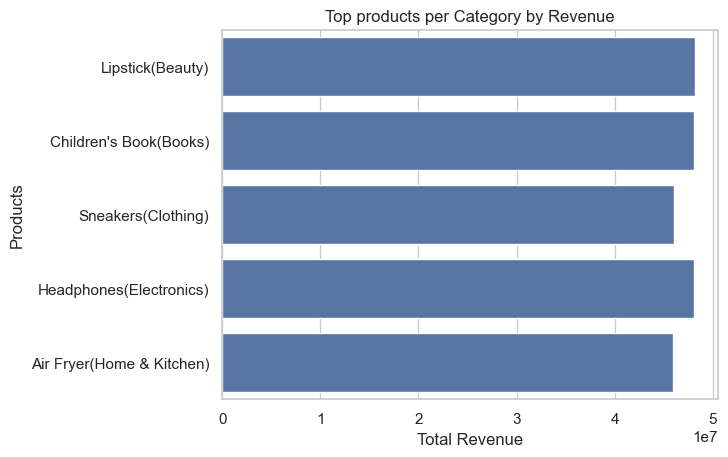

In [46]:
#visualising results
top_product_by_category['label'] = (top_product_by_category['product_name'] + '(' + top_product_by_category['product_category'] + ')')

sns.barplot(
    x = 'total_revenue',
    y = 'label',
    data = top_product_by_category
)

plt.xlabel('Total Revenue')
plt.ylabel('Products')
plt.title("Top products per Category by Revenue")
plt.show()

Insight : Top-performing products dominate revenue within their respective categories, highlighting key drivers of the sales.

PROBLEM 18: CUSTOMERS WHO ORDERED MORE THAN 5 TIMES AND SPENT MORE THAN 50000

In [47]:
#customers who ordered more than 5 times and spent more than 50000
pd.read_sql("""
SELECT customer_id, COUNT(*) AS total_orders, SUM(total_sales_inr) AS total_spent
FROM orders
GROUP BY customer_id
HAVING SUM(total_sales_inr) > 50000 AND COUNT(*) > 5
""", conn)

,customer_id,total_orders,total_spent
0,CUST1103,6,492523.92
1,CUST1235,6,478449.95
2,CUST1508,6,509822.67
3,CUST1627,6,398710.54
4,CUST1847,6,264900.26
...,...,...,...
75,CUST9505,7,366240.02
76,CUST9589,6,491268.66
77,CUST9620,6,547795.59
78,CUST9779,6,456976.02


PROBLEM 19: THE DAY WITH THE HIGHEST SALES

In [48]:
#Day with highest sales
pd.read_sql("""
SELECT strftime('%Y-%m-%d', order_date) AS date, MAX(total_sales_inr) AS highest_sales
FROM orders
ORDER BY highest_sales DESC
""", conn)

,date,highest_sales
0,2025-03-04,249955.5
